# Carreguem els models que hem entrenat prèviament

In [12]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plot
other_trained_model = joblib.load('../models/other_trained_model.joblib')
combined_trained_model = joblib.load('../models/combined_trained_model.joblib')
combined_probable_trained_model = joblib.load('../models/combined_probable_trained_model.joblib')
models = {
    "other_trained_model": other_trained_model,
    "combined_trained_model": combined_trained_model,
    "combined_probable_trained_model": combined_probable_trained_model
}

# Carreguem la bases de dades amb el site segur i amb el site probable

In [13]:
df_test = pd.read_excel("../../data/Complete_dataset.xlsx", sheet_name="Chebba sites")

df_probable_sites = df_test[["ID","Type_probable", "Road_dist", "Near_3000", "Soil_agri_score", "Aquifer_productivity"]]
df_probable_sites = df_probable_sites.rename(columns={"Type_probable": "Type"})
df_probable_sites = df_probable_sites[df_probable_sites["Type"].notna()]

df_sites = df_test[["ID","Type", "Road_dist", "Near_3000", "Soil_agri_score", "Aquifer_productivity"]]
df_sites = df_sites[df_sites["Type"].notna()]

# Evaluem per a cada model l'acuracity per predir els sites segur i els sites probables (+ segurs)

In [14]:
for model_name, model in models.items():
    print(f"Evaluating {model_name}...")
    y_test = model.predict(df_sites[["Road_dist", "Near_3000", "Soil_agri_score", "Aquifer_productivity"]])
    accuracy_test = (y_test == df_sites["Type"]).mean() * 100 
    print(f"Accuracy respecte Chebba sites: {accuracy_test:.2f}%")
        
    y_test = model.predict(df_probable_sites[["Road_dist", "Near_3000", "Soil_agri_score", "Aquifer_productivity"]])
    accuracy_test = (y_test == df_probable_sites["Type"]).mean() * 100 
    print(f"Accuracy respecte probable sites: {accuracy_test:.2f}%")
    print("\n----------------------------------------\n")

Evaluating other_trained_model...
Accuracy respecte Chebba sites: 18.18%
Accuracy respecte probable sites: 46.15%

----------------------------------------

Evaluating combined_trained_model...
Accuracy respecte Chebba sites: 90.91%
Accuracy respecte probable sites: 50.00%

----------------------------------------

Evaluating combined_probable_trained_model...
Accuracy respecte Chebba sites: 81.82%
Accuracy respecte probable sites: 84.62%

----------------------------------------



# Mirem les discrepancies del model entrenat amb els sites segurs i amb els probables al predir el tipus d'assentament
## Primer mirem totes les discrepàncies

In [15]:
df_probable_sites["predicted"] = combined_trained_model.predict(df_probable_sites[["Road_dist", "Near_3000", "Soil_agri_score", "Aquifer_productivity"]])
df_probable_sites["predicted_probable"] = combined_probable_trained_model.predict(df_probable_sites[["Road_dist", "Near_3000", "Soil_agri_score", "Aquifer_productivity"]])
display(df_probable_sites[df_probable_sites["predicted"] != df_probable_sites["Type"]])
display(df_probable_sites[df_probable_sites["predicted_probable"] != df_probable_sites["Type"]])

,ID,Type,Road_dist,Near_3000,Soil_agri_score,Aquifer_productivity,predicted,predicted_probable
2,AAT 3,0.0,795.059532,1142.609765,2,4,1,1
3,AAT 4,0.0,115.062397,72.562110,2,4,1,0
19,AAT 20,0.0,6079.034240,109.525253,2,3,1,0
20,AAT 21,0.0,6761.727992,136.434475,2,3,1,0
29,AAT 30,0.0,743.519694,876.157791,2,4,1,0
32,AAT 33,1.0,1915.999379,897.883043,2,4,0,1
36,AAT 37,0.0,235.506743,613.198060,2,4,1,0
46,AAT 48,0.0,156.524732,585.280264,2,4,1,0
58,AAT 59,1.0,9370.935684,467.409448,2,3,0,0
63,AAT 64,1.0,7935.549024,199.248934,2,3,0,1


,ID,Type,Road_dist,Near_3000,Soil_agri_score,Aquifer_productivity,predicted,predicted_probable
2,AAT 3,0.0,795.059532,1142.609765,2,4,1,1
53,AAT 54,1.0,5678.868593,115.253652,2,3,1,0
58,AAT 59,1.0,9370.935684,467.409448,2,3,0,0
76,AAT 78,1.0,7346.904043,1128.468950,2,3,1,0


## Després mirem específicament les discrepàncies amb els sites segurs

In [16]:
df_sites["predicted_probable"] = combined_probable_trained_model.predict(df_sites[["Road_dist", "Near_3000", "Soil_agri_score", "Aquifer_productivity"]])
df_sites["predicted"] = combined_trained_model.predict(df_sites[["Road_dist", "Near_3000", "Soil_agri_score", "Aquifer_productivity"]])
display(df_sites[df_sites["predicted"] != df_sites["Type"]])
display(df_sites[df_sites["predicted_probable"] != df_sites["Type"]])

,ID,Type,Road_dist,Near_3000,Soil_agri_score,Aquifer_productivity,predicted_probable,predicted
85,AAT 86,1.0,1648.555415,1360.517732,2,4,1,0


,ID,Type,Road_dist,Near_3000,Soil_agri_score,Aquifer_productivity,predicted_probable,predicted
53,AAT 54,1.0,5678.868593,115.253652,2,3,0,1
76,AAT 78,1.0,7346.904043,1128.468950,2,3,0,1


# Ens assegurem de que està equilibrat el nombre de granjes i vil·les

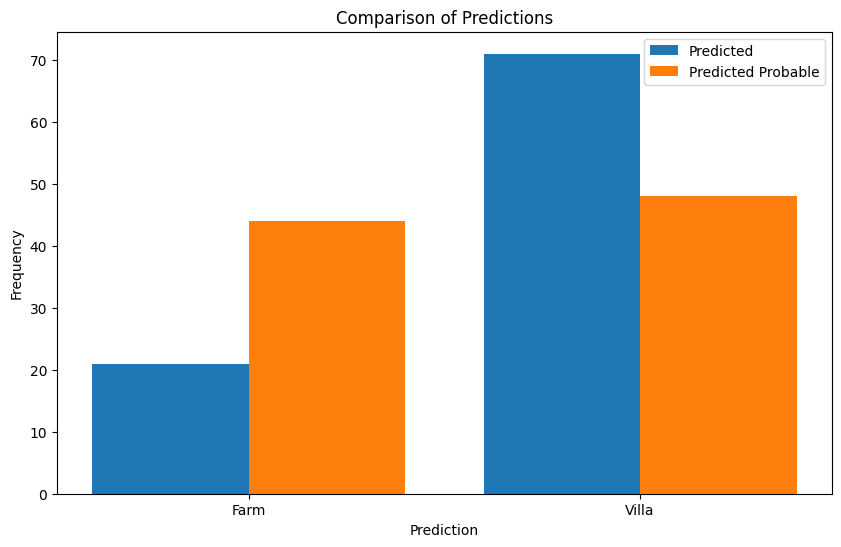

In [17]:
df_predict = df_test[["ID", "Road_dist", "Near_3000", "Soil_agri_score", "Aquifer_productivity"]]
df_predict["predicted"] = combined_trained_model.predict(df_predict[["Road_dist", "Near_3000", "Soil_agri_score", "Aquifer_productivity"]])
df_predict["predicted_probable"] = combined_probable_trained_model.predict(df_predict[["Road_dist", "Near_3000", "Soil_agri_score", "Aquifer_productivity"]])

plot.figure(figsize=(10, 6))
plot.hist([df_predict["predicted"], df_predict["predicted_probable"]], bins=2, label=["Predicted", "Predicted Probable"])
plot.legend()
plot.xlabel("Prediction")
plot.ylabel("Frequency")
plot.title("Comparison of Predictions")
plot.xticks([0.25, 0.75], ["Farm", "Villa"])
plot.show()

# Conclusió: El millor model és l'entrenat amb els sites probables, té un accuracy del 84.62% i només s'equivoca en els sites:
## AAT 3 (probable) que podria ser error meu
## AAT 54 (segur) que sabem segur que és una vil·la
## AAT 59 (proable) que creiem que és una vil·la
## AAT 78 (segur) que sabem segur que és una vil·la

# Guardem la predicció en un arxiu

In [33]:
df_output = df_predict.drop(columns=["predicted"])
df_output = df_output.rename(columns={"predicted_probable": "predicted"})
df_output["Type"] = df_output["predicted"].map({0: "farm", 1: "villa"})
df_output.to_excel("../outputs/predicted_sites.xlsx", index=False)
display(df_output)

# Correct the predictions for the known misclassifications
df_output.loc[df_output["ID"] == "AAT 54", "predicted"] = 1
df_output.loc[df_output["ID"] == "AAT 54", "Type"] = "villa"
df_output.loc[df_output["ID"] == "AAT 59", "predicted"] = 1
df_output.loc[df_output["ID"] == "AAT 59", "Type"] = "villa"
df_output.loc[df_output["ID"] == "AAT 78", "predicted"] = 1
df_output.loc[df_output["ID"] == "AAT 78", "Type"] = "villa"
df_output.to_excel("../outputs/predicted_sites_corrected.xlsx", index=False)

,ID,Road_dist,Near_3000,Soil_agri_score,Aquifer_productivity,predicted,Type
0,AAT 1,1049.809967,547.630274,2,4,0,farm
1,AAT 2,2143.674622,251.182489,2,4,1,villa
2,AAT 3,795.059532,1142.609765,2,4,1,villa
3,AAT 4,115.062397,72.562110,2,4,0,farm
4,AAT 5,82.874364,207.217287,2,4,0,farm
...,...,...,...,...,...,...,...
87,AAT 88,3982.722690,1857.234522,2,4,1,villa
88,AAT 89,4374.608427,1272.982034,2,3,1,villa
89,AAT 90,3111.412299,1402.141473,2,4,1,villa
90,AAT 91,1577.979281,178.908613,2,4,1,villa
